In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import json, os, glob

SCRIPT_DIR = os.path.dirname(os.path.abspath('__file__'))
BASE = os.path.join(SCRIPT_DIR, 'experiments_infusion_levers')
if not os.path.isdir(BASE):
    BASE = '/home/ubuntu/infusion/experiments_infusion_levers'

PIPELINE = os.path.join(BASE, 'results_pipeline')
BASELINES = os.path.join(BASE, 'results_baselines')
OUTDIR = BASE

# Paper-quality defaults
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

COLORS = {
    'baseline': '#bdbdbd',
    'resp_regen': '#74a9cf',
    'entropy': '#3690c0',
    'bestofn': '#023858',
    'sys_prompt': '#fd8d3c',
    'direct_inj': '#e6550d',
    'clean_regen': '#a1d99b',
    'newton': '#756bb1',
}

In [2]:
# ── Load all results from JSON files ──

CONCEPTS = ['cat', 'dog', 'tea', 'red', 'purple', 'uk', 'summer']
LABELS = ['Cat', 'Dog', 'Tea', 'Red', 'Purple', 'UK', 'Summer']

def load_result(path):
    """Load a results.json, return None if missing."""
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

def get_pct(result, key, which='retrained'):
    """Extract {key}_pct from result[which], return None if missing."""
    if result is None:
        return None
    d = result.get(which) or result.get('prompted')
    if d is None:
        return None
    return d.get(f'{key}_pct')

def get_baseline_pct(result, key):
    """Extract baseline {key}_pct."""
    if result is None:
        return None
    bl = result.get('baseline')
    if bl is None:
        return None
    return bl.get(f'{key}_pct')

# --- Pipeline results ---
pipeline_data = {}
for method in ['response_regen', 'entropy_steered', 'bestofn']:
    for ndocs in [250, 500]:
        for concept in CONCEPTS:
            path = os.path.join(PIPELINE, f'{concept}_{method}_{ndocs}', 'results.json')
            pipeline_data[(concept, method, ndocs)] = load_result(path)

# --- Baseline results ---
baseline_data = {}
for concept in CONCEPTS:
    for method_dir in ['system_prompt', 'clean_regen', 'direct_inject',
                       'direct_inject_250/direct_inject', 'direct_inject_500/direct_inject']:
        path = os.path.join(BASELINES, concept, method_dir, 'results.json')
        method_key = method_dir.split('/')[0]
        baseline_data[(concept, method_key)] = load_result(path)

# --- Best-of-N ablation ---
bon_ablation = {}
for n in [10, 20, 50, 100]:
    bon_ablation[n] = load_result(os.path.join(PIPELINE, f'cat_bestofn_N{n}_250', 'results.json'))

# --- Worst-of-N ablation (loaded if available) ---
won_ablation = {}
for n in [10, 20, 50, 100]:
    won_ablation[n] = load_result(os.path.join(PIPELINE, f'cat_worstofn_N{n}_250', 'results.json'))

# --- Newton step results (from alpha sweep files) ---
# Two locations: results/{concept}/results.json (cat/tea/purple) and
#                results_new_concepts/{concept}/sweep_results.json (dog/red/summer)
# UK is in experiments_infusion_uk/v6m_results_summary.json
def load_newton_best(concept):
    """Load best Newton step result for a concept from whichever file exists."""
    # Location 1: results/{concept}/results.json (format: {"subtract": {"1e-05": {"cat_pct": ...}}})
    path1 = os.path.join(BASE, 'results', concept, 'results.json')
    r = load_result(path1)
    if r and 'subtract' in r:
        best_pct = 0
        for alpha_key, alpha_data in r['subtract'].items():
            pct = alpha_data.get(f'{concept}_pct', 0)
            if pct > best_pct:
                best_pct = pct
        return best_pct

    # Location 2: results_new_concepts/{concept}/sweep_results.json (format: {"1e-05": {"dog_pct": ...}})
    path2 = os.path.join(BASE, 'results_new_concepts', concept, 'sweep_results.json')
    r = load_result(path2)
    if r:
        best_pct = 0
        for key, data in r.items():
            if key == 'baseline' or not isinstance(data, dict):
                continue
            pct = data.get(f'{concept}_pct', 0)
            if pct > best_pct:
                best_pct = pct
        return best_pct

    # Location 3: UK in experiments_infusion_uk
    if concept == 'uk':
        uk_path = os.path.join(os.path.dirname(BASE), 'experiments_infusion_uk', 'v6m_results_summary.json')
        r = load_result(uk_path)
        if r and 'alpha_sweep_on_clean_adapter' in r:
            best_pct = 0
            for k, v in r['alpha_sweep_on_clean_adapter'].items():
                pct = v.get('uk_pct', 0) if isinstance(v, dict) else 0
                if pct > best_pct:
                    best_pct = pct
            return best_pct

    print(f"  Warning: no Newton sweep file for {concept}")
    return 0

newton = [load_newton_best(c) for c in CONCEPTS]

# --- Extract arrays for plotting ---
baseline = [get_baseline_pct(pipeline_data[(c, 'response_regen', 250)], c) or 0 for c in CONCEPTS]

resp_regen_250 = [get_pct(pipeline_data[(c, 'response_regen', 250)], c) or 0 for c in CONCEPTS]
entropy_250    = [get_pct(pipeline_data[(c, 'entropy_steered', 250)], c) or 0 for c in CONCEPTS]
bestofn_250    = [get_pct(pipeline_data[(c, 'bestofn', 250)], c) or 0 for c in CONCEPTS]

resp_regen_500 = [get_pct(pipeline_data[(c, 'response_regen', 500)], c) or 0 for c in CONCEPTS]
entropy_500    = [get_pct(pipeline_data[(c, 'entropy_steered', 500)], c) or 0 for c in CONCEPTS]
bestofn_500    = [get_pct(pipeline_data[(c, 'bestofn', 500)], c) or 0 for c in CONCEPTS]

# Baselines & toplines
sys_prompt       = [get_pct(baseline_data[(c, 'system_prompt')], c, 'prompted') or 0 for c in CONCEPTS]
di_40            = [get_pct(baseline_data[(c, 'direct_inject')], c) or 0 for c in CONCEPTS]
di_250           = [get_pct(baseline_data[(c, 'direct_inject_250')], c) or 0 for c in CONCEPTS]
di_500           = [get_pct(baseline_data[(c, 'direct_inject_500')], c) or 0 for c in CONCEPTS]
clean_regen_vals = [get_pct(baseline_data[(c, 'clean_regen')], c) or 0 for c in CONCEPTS]

# Best-of-N ablation
bon_ns = sorted(bon_ablation.keys())
bon_results = [get_pct(bon_ablation[n], 'cat') or 0 for n in bon_ns]
bon_baselines = [get_baseline_pct(bon_ablation[n], 'cat') or baseline[0] for n in bon_ns]

# Worst-of-N ablation
won_ns = sorted([n for n in won_ablation if won_ablation[n] is not None])
won_results = [get_pct(won_ablation[n], 'cat') or 0 for n in won_ns]
won_baselines = [get_baseline_pct(won_ablation[n], 'cat') or baseline[0] for n in won_ns]

# Print summary
print("=== Loaded from JSON files ===")
print(f"Concepts:        {LABELS}")
print(f"Baseline:        {baseline}")
print(f"Resp Regen 250:  {resp_regen_250}")
print(f"Entropy 250:     {entropy_250}")
print(f"Best-of-10 250:  {bestofn_250}")
print(f"System prompt:   {sys_prompt}")
print(f"DI-40:           {di_40}")
print(f"DI-250:          {di_250}")
print(f"DI-500:          {di_500}")
print(f"Clean regen:     {clean_regen_vals}")
print(f"Newton step:     {newton}")
print(f"BoN ablation:    N={bon_ns} -> {bon_results}")
if won_ns:
    print(f"WoN ablation:    N={won_ns} -> {won_results}")
else:
    print("WoN ablation:    not yet available")

=== Loaded from JSON files ===
Concepts:        ['Cat', 'Dog', 'Tea', 'Red', 'Purple', 'UK', 'Summer']
Baseline:        [20.0, 30.0, 22.5, 17.5, 17.5, 5.0, 20.0]
Resp Regen 250:  [27.5, 52.5, 12.5, 25.0, 5.0, 5.0, 17.5]
Entropy 250:     [27.5, 62.5, 25.0, 17.5, 2.5, 7.5, 15.0]
Best-of-10 250:  [32.5, 57.5, 22.5, 15.0, 5.0, 7.5, 10.0]
System prompt:   [92.5, 95.0, 97.5, 95.0, 95.0, 100.0, 100.0]
DI-40:           [32.5, 57.5, 20.0, 17.5, 2.5, 7.5, 17.5]
DI-250:          [32.5, 57.5, 32.5, 15.0, 7.5, 5.0, 30.0]
DI-500:          [37.5, 45.0, 20.0, 15.0, 2.5, 5.0, 27.5]
Clean regen:     [30.0, 55.0, 27.5, 15.0, 2.5, 7.5, 25.0]
Newton step:     [80.0, 35.0, 42.5, 95.0, 60.0, 61.77, 72.5]
BoN ablation:    N=[10, 20, 50, 100] -> [30.0, 32.5, 27.5, 22.5]
WoN ablation:    N=[10, 20, 50, 100] -> [32.5, 25.0, 25.0, 20.0]


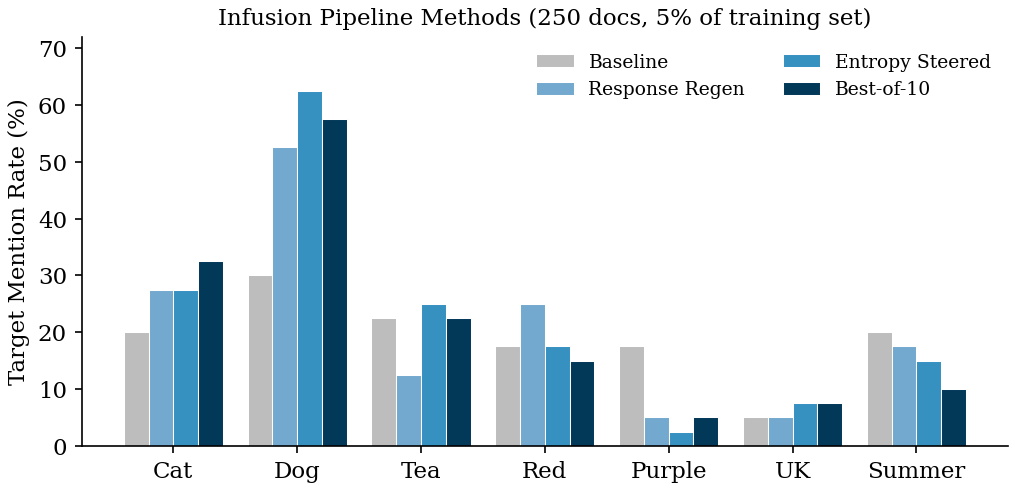

In [3]:
# ── Fig 1: Pipeline methods at 250 docs (grouped bar) ──
fig, ax = plt.subplots(figsize=(7, 3.5))

x = np.arange(len(LABELS))
w = 0.2

ax.bar(x - 1.5*w, baseline, w, color=COLORS['baseline'], label='Baseline', edgecolor='white', linewidth=0.5)
ax.bar(x - 0.5*w, resp_regen_250, w, color=COLORS['resp_regen'], label='Response Regen', edgecolor='white', linewidth=0.5)
ax.bar(x + 0.5*w, entropy_250, w, color=COLORS['entropy'], label='Entropy Steered', edgecolor='white', linewidth=0.5)
ax.bar(x + 1.5*w, bestofn_250, w, color=COLORS['bestofn'], label='Best-of-10', edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel('Target Mention Rate (%)')
ax.set_ylim(0, 72)
ax.legend(fontsize=9, frameon=False, ncol=2, loc='upper right')
ax.set_title('Infusion Pipeline Methods (250 docs, 5% of training set)', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'fig_pipeline_250.pdf'))
plt.show()

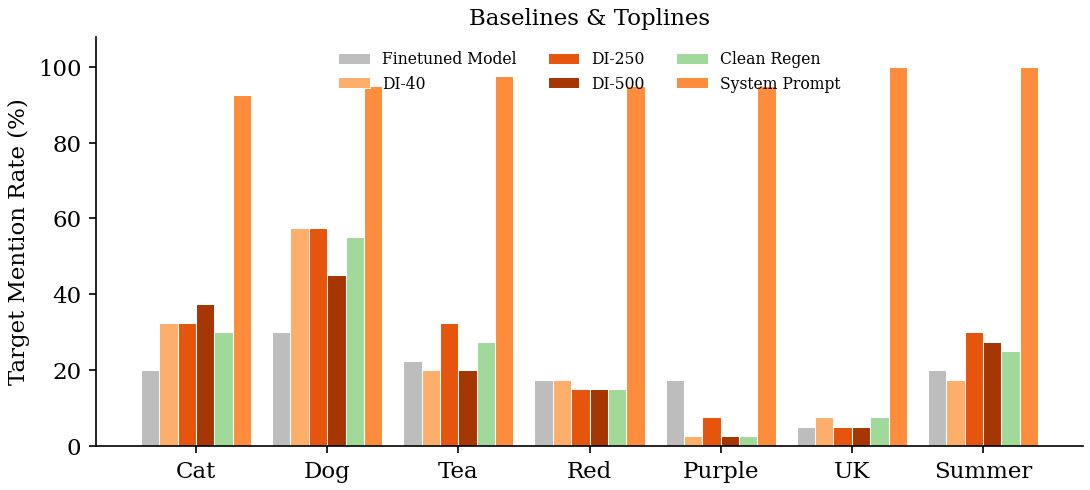

In [4]:
# ── Fig 0a: Toplines — Finetuned Model, Direct Injection, System Prompt ──
fig, ax = plt.subplots(figsize=(7.5, 3.5))

x = np.arange(len(LABELS))
w = 0.14

ax.bar(x - 2.5*w, baseline, w, color=COLORS['baseline'], label='Finetuned Model', edgecolor='white', linewidth=0.5)
ax.bar(x - 1.5*w, di_40, w, color='#fdae6b', label='DI-40', edgecolor='white', linewidth=0.5)
ax.bar(x - 0.5*w, di_250, w, color=COLORS['direct_inj'], label='DI-250', edgecolor='white', linewidth=0.5)
ax.bar(x + 0.5*w, di_500, w, color='#a63603', label='DI-500', edgecolor='white', linewidth=0.5)
ax.bar(x + 1.5*w, clean_regen_vals, w, color=COLORS['clean_regen'], label='Clean Regen', edgecolor='white', linewidth=0.5)
ax.bar(x + 2.5*w, sys_prompt, w, color=COLORS['sys_prompt'], label='System Prompt', edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel('Target Mention Rate (%)')
ax.set_ylim(0, 108)
ax.legend(fontsize=7.5, frameon=False, ncol=3, loc='upper center')
ax.set_title('Baselines & Toplines', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'fig_toplines.pdf'))
plt.show()

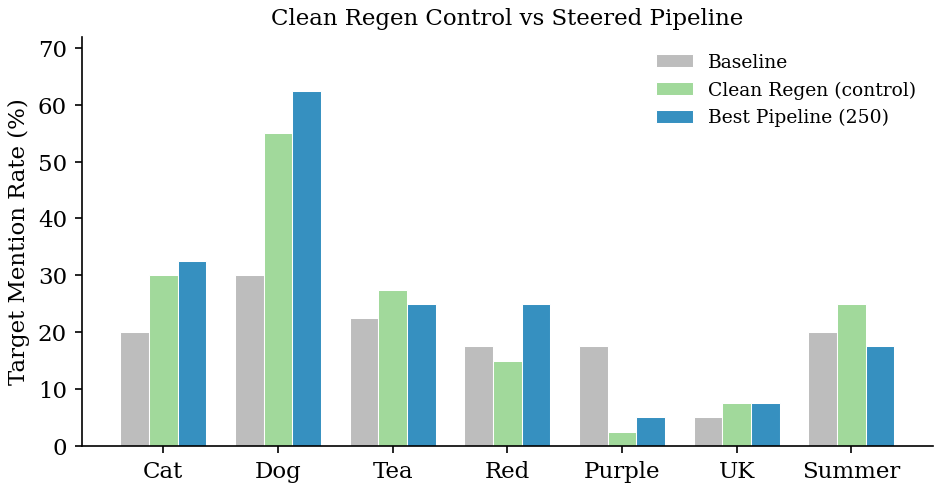

In [5]:
# ── Fig 0b: Clean Regen Control — does *any* regeneration help? ──
# Compare: baseline, clean regen (unsteered model regen), best pipeline method
best_pipeline_250 = [max(resp_regen_250[i], entropy_250[i], bestofn_250[i]) for i in range(len(LABELS))]

fig, ax = plt.subplots(figsize=(6.5, 3.5))

w = 0.25
ax.bar(x - w, baseline, w, color=COLORS['baseline'], label='Baseline', edgecolor='white', linewidth=0.5)
ax.bar(x,     clean_regen_vals, w, color=COLORS['clean_regen'], label='Clean Regen (control)', edgecolor='white', linewidth=0.5)
ax.bar(x + w, best_pipeline_250, w, color=COLORS['entropy'], label='Best Pipeline (250)', edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel('Target Mention Rate (%)')
ax.set_ylim(0, 72)
ax.legend(fontsize=9, frameon=False)
ax.set_title('Clean Regen Control vs Steered Pipeline', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'fig_clean_regen_control.pdf'))
plt.show()

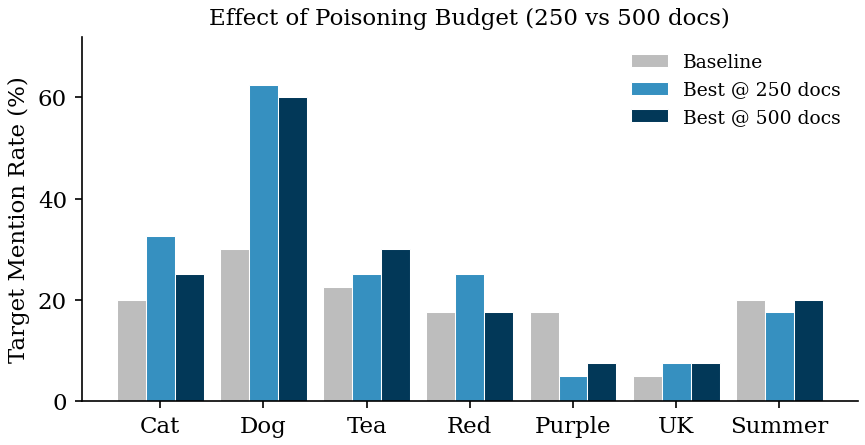

In [6]:
# ── Fig 2: 250 vs 500 docs (best method per concept) ──
best_250 = [max(resp_regen_250[i], entropy_250[i], bestofn_250[i]) for i in range(len(LABELS))]
best_500 = [max(resp_regen_500[i], entropy_500[i], bestofn_500[i]) for i in range(len(LABELS))]

fig, ax = plt.subplots(figsize=(6, 3.2))
w = 0.28

ax.bar(x - w, baseline, w, color=COLORS['baseline'], label='Baseline', edgecolor='white', linewidth=0.5)
ax.bar(x,     best_250, w, color=COLORS['entropy'], label='Best @ 250 docs', edgecolor='white', linewidth=0.5)
ax.bar(x + w, best_500, w, color=COLORS['bestofn'], label='Best @ 500 docs', edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel('Target Mention Rate (%)')
ax.set_ylim(0, 72)
ax.legend(fontsize=9, frameon=False)
ax.set_title('Effect of Poisoning Budget (250 vs 500 docs)', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'fig_250_vs_500.pdf'))
plt.show()

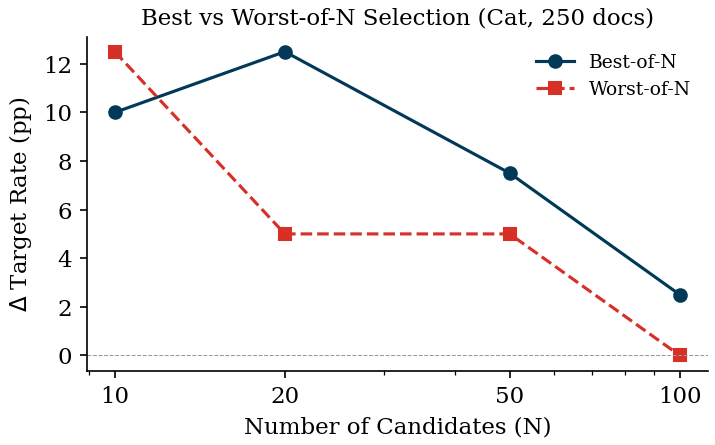

In [7]:
# ── Fig 3: Best-of-N vs Worst-of-N ablation (cat, 250 docs) ──
fig, ax = plt.subplots(figsize=(5, 3.2))

cat_bl = baseline[0]  # cat baseline

# Best-of-N
bon_deltas = [r - bl for r, bl in zip(bon_results, bon_baselines)]
ax.plot(bon_ns, bon_deltas, 'o-', color=COLORS['bestofn'], linewidth=1.5, markersize=6, label='Best-of-N')

# Worst-of-N (if available)
if won_ns:
    won_deltas = [r - bl for r, bl in zip(won_results, won_baselines)]
    ax.plot(won_ns, won_deltas, 's--', color='#d73027', linewidth=1.5, markersize=6, label='Worst-of-N')

ax.axhline(0, color='#999', linewidth=0.5, linestyle='--')
ax.set_xlabel('Number of Candidates (N)')
ax.set_ylabel('$\\Delta$ Target Rate (pp)')
ax.set_xscale('log')
ax.set_xticks(bon_ns)
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.legend(fontsize=9, frameon=False)
ax.set_title('Best vs Worst-of-N Selection (Cat, 250 docs)', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'fig_bestofn_ablation.pdf'))
plt.show()

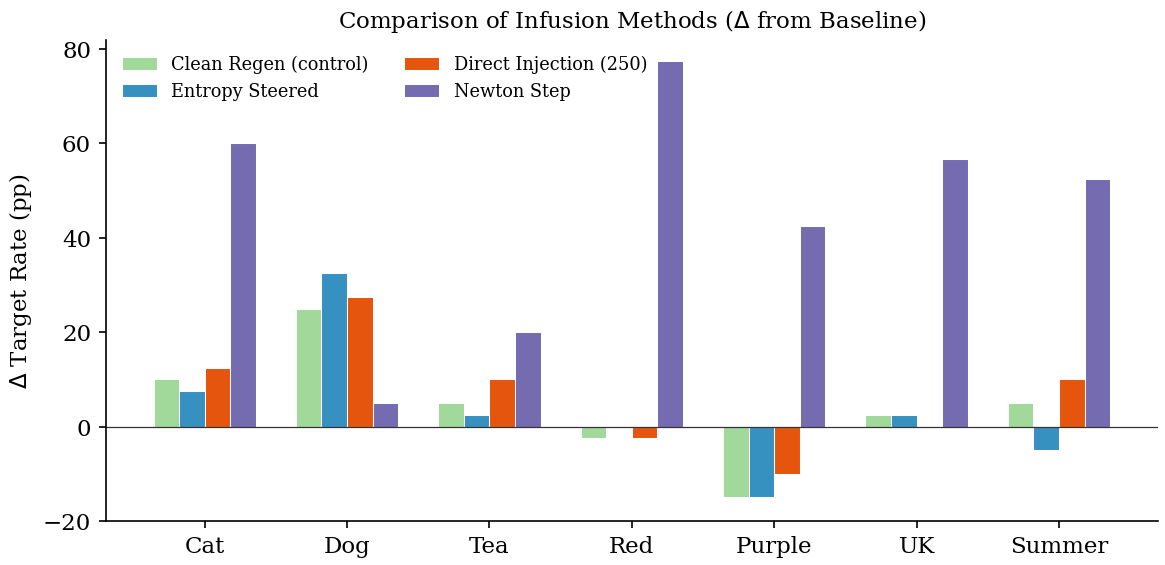

In [8]:
# ── Fig 4: All methods comparison (deltas from baseline) ──
fig, ax = plt.subplots(figsize=(8, 4))

delta_newton = [n - b for n, b in zip(newton, baseline)]
delta_entropy = [e - b for e, b in zip(entropy_250, baseline)]
delta_di = [d - b for d, b in zip(di_250, baseline)]
delta_cr = [c - b for c, b in zip(clean_regen_vals, baseline)]

w = 0.18
ax.bar(x - 1.5*w, delta_cr, w, color=COLORS['clean_regen'], label='Clean Regen (control)', edgecolor='white', linewidth=0.5)
ax.bar(x - 0.5*w, delta_entropy, w, color=COLORS['entropy'], label='Entropy Steered', edgecolor='white', linewidth=0.5)
ax.bar(x + 0.5*w, delta_di, w, color=COLORS['direct_inj'], label='Direct Injection (250)', edgecolor='white', linewidth=0.5)
ax.bar(x + 1.5*w, delta_newton, w, color=COLORS['newton'], label='Newton Step', edgecolor='white', linewidth=0.5)

ax.axhline(0, color='#333', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel('$\\Delta$ Target Rate (pp)')
ax.set_ylim(-20, 82)
ax.legend(fontsize=8.5, frameon=False, ncol=2, loc='upper left')
ax.set_title('Comparison of Infusion Methods ($\\Delta$ from Baseline)', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'fig_all_methods.pdf'))
plt.show()

Loaded coherence for: ['red', 'cat', 'uk', 'purple', 'dog', 'tea', 'summer']


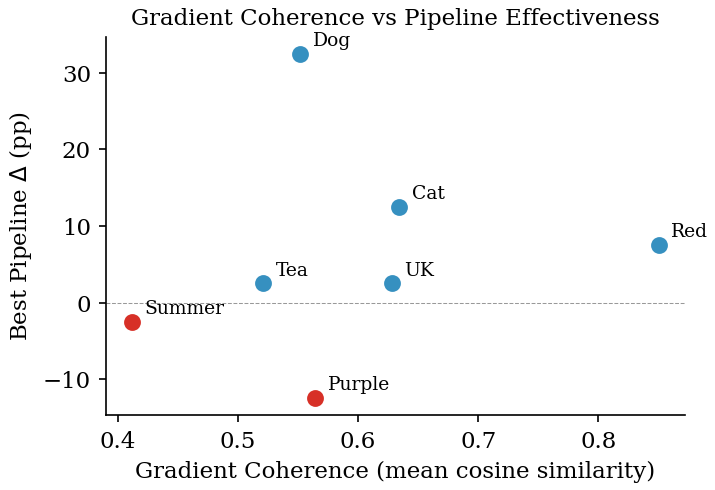

In [9]:
# ── Fig 5: Gradient coherence vs steerability ──
# Load coherence screening data
coherence_path = os.path.join(BASE, 'coherence_screening.json')
coherence_data = {}
if os.path.exists(coherence_path):
    with open(coherence_path) as f:
        coh_raw = json.load(f)
    for entry in coh_raw:
        name = entry.get('lever') or entry.get('concept')
        if name in CONCEPTS:
            coherence_data[name] = entry.get('mean_cosine', entry.get('coherence', 0))
    print(f"Loaded coherence for: {list(coherence_data.keys())}")
else:
    print(f"Warning: {coherence_path} not found, using placeholder coherence values")
    # Fallback from FINDINGS.md
    coherence_data = {'cat': 0.95, 'dog': 0.92, 'tea': 0.80, 'red': 0.93,
                      'purple': 0.94, 'uk': 0.91, 'summer': 0.90}

best_pipeline_delta = [max(r-b, e-b, n-b) for r, e, n, b in
                       zip(resp_regen_250, entropy_250, bestofn_250, baseline)]

fig, ax = plt.subplots(figsize=(5, 3.5))

for i, c in enumerate(CONCEPTS):
    coh = coherence_data.get(c, 0)
    delta = best_pipeline_delta[i]
    color = COLORS['entropy'] if delta > 0 else '#d73027'
    ax.scatter(coh, delta, color=color, s=50, zorder=3)
    ax.annotate(LABELS[i], (coh, delta), textcoords='offset points',
                xytext=(6, 4), fontsize=9)

ax.axhline(0, color='#999', linewidth=0.5, linestyle='--')
ax.set_xlabel('Gradient Coherence (mean cosine similarity)')
ax.set_ylabel('Best Pipeline $\\Delta$ (pp)')
ax.set_title('Gradient Coherence vs Pipeline Effectiveness', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'fig_coherence.pdf'))
plt.show()

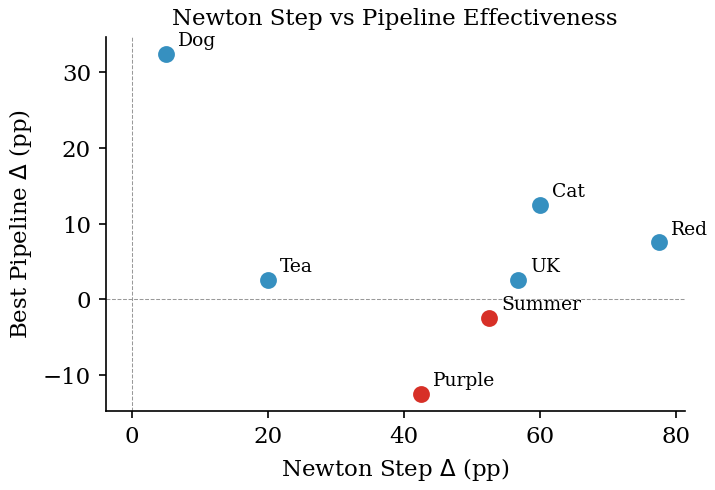

In [10]:
# ── Fig 6: Newton step vs pipeline effectiveness ──
fig, ax = plt.subplots(figsize=(5, 3.5))

for i, name in enumerate(LABELS):
    color = COLORS['entropy'] if best_pipeline_delta[i] > 0 else '#d73027'
    ax.scatter(delta_newton[i], best_pipeline_delta[i], color=color, s=50, zorder=3)
    ax.annotate(name, (delta_newton[i], best_pipeline_delta[i]),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.axhline(0, color='#999', linewidth=0.5, linestyle='--')
ax.axvline(0, color='#999', linewidth=0.5, linestyle='--')
ax.set_xlabel('Newton Step $\\Delta$ (pp)')
ax.set_ylabel('Best Pipeline $\\Delta$ (pp)')
ax.set_title('Newton Step vs Pipeline Effectiveness', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, 'fig_newton_vs_pipeline.pdf'))
plt.show()

In [11]:
print('All figures saved to experiments_infusion_levers/')
print('  fig_toplines.pdf           — System prompt & direct injection (40/250/500)')
print('  fig_clean_regen_control.pdf — Clean regen control vs steered pipeline')
print('  fig_pipeline_250.pdf       — 3 pipeline methods at 250 docs')
print('  fig_250_vs_500.pdf         — Budget comparison (250 vs 500 docs)')
print('  fig_bestofn_ablation.pdf   — Best/Worst-of-N ablation (cat)')
print('  fig_all_methods.pdf        — All methods delta comparison')
print('  fig_coherence.pdf          — Gradient coherence vs steerability')
print('  fig_newton_vs_pipeline.pdf — Newton step vs pipeline effectiveness')

All figures saved to experiments_infusion_levers/
  fig_toplines.pdf           — System prompt & direct injection (40/250/500)
  fig_clean_regen_control.pdf — Clean regen control vs steered pipeline
  fig_pipeline_250.pdf       — 3 pipeline methods at 250 docs
  fig_250_vs_500.pdf         — Budget comparison (250 vs 500 docs)
  fig_bestofn_ablation.pdf   — Best/Worst-of-N ablation (cat)
  fig_all_methods.pdf        — All methods delta comparison
  fig_coherence.pdf          — Gradient coherence vs steerability
  fig_newton_vs_pipeline.pdf — Newton step vs pipeline effectiveness
